# Hybrid Model (Prophet + XGBoost)
Using Prophet for baseline trend/seasonality, then XGBoost to correct residuals

### 1. Load and Prepare Data

In [1]:
import pandas as pd
import numpy as np
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
from math import sqrt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ========== CONFIGURATION: CHANGE THESE VALUES ==========
# Choose which dataset to use: 1, 2, 3, 4, 5, or 6
DATASET_VERSION = 5  # Change this to test other feature sets

# Define features for each dataset
FEATURE_CONFIGS = {
    1: {
        'file': '../data/final_features_1.csv',
        'features': [
            "platt_apag_mom_pct",
            "platt_crude_mom_pct",
            "temp_avg",
            "precip_avg",
            "threshold_temp_days",
            "threshold_rainy_days",
            "possible_working_days",
            "avg_weight"
        ],
        'name': 'final_features_1.csv'
    },
    2: {
        'file': '../data/final_features_2.csv',
        'features': [
            "season_sin",
            "season_cos",
            "temp_avg",
            "precip_avg",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight"
        ],
        'name': 'final_features_2.csv'
    },
    3: {
        'file': '../data/final_features_4.csv',
        'features': [
            "season_sin",
            "season_cos",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight",
            "demand_lag1",
            "demand_lag3",
            "ap_price_weight_lag1",
            "ap_price_weight_lag3",
            "ap_price_weight_lag6",
            "crude_price_weight_lag1",
            "crude_price_weight_lag3",
            "crude_price_weight_lag6",
            "demand_rollmean_3",
            "crude_price_weight_rollmean_3",
            "crude_price_weight_rollmean_6"
        ],
        'name': 'final_features_4.csv'
    },
    4: {
        'file': '../data/final_features_5.csv',
        'features': [
            "season_sin",
            "season_cos",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight",
            "demand_lag1",
            "demand_lag3",
            "ap_price_weight_lag1",
            "ap_price_weight_lag3",
            "ap_price_weight_lag6",
            "crude_price_weight_lag1",
            "crude_price_weight_lag3",
            "crude_price_weight_lag6",
            "demand_rollmean_3",
            "crude_price_weight_rollmean_3",
            "crude_price_weight_rollmean_6"
        ],
        'name': 'final_features_5.csv'
    },
    5: {
        'file': '../data/final_features_6.csv',
        'features': [
            "season_sin",
            "season_cos",
            "possible_working_days",
            "avg_weight",
            "ap_price_weight",
            "crude_price_weight",
            "demand_lag1",
            "demand_lag3",
            "ap_price_weight_lag1",
            "ap_price_weight_lag3",
            "ap_price_weight_lag6",
            "crude_price_weight_lag1",
            "crude_price_weight_lag3",
            "crude_price_weight_lag6",
            "demand_rollmean_3",
            "crude_price_weight_rollmean_3",
            "crude_price_weight_rollmean_6"
        ],
        'name': 'final_features_6.csv'
    },
}
# ========================================================

# Load selected dataset
config = FEATURE_CONFIGS[DATASET_VERSION]
df = pd.read_csv(config['file'])
df["ds"] = pd.to_datetime(df["date"], format="%Y%m") + pd.offsets.MonthEnd(0)
df = df.rename(columns={"demand": "y"})
reg_cols = config['features']
dataset_name = config['name']

# Ensure numeric types
for col in reg_cols:
    df[col] = df[col].astype(float)

# Train/validation split (last 32 months for validation)
cutoff = df["ds"].max() - pd.DateOffset(months=32)
df_train = df[["ds", "y"] + reg_cols].copy()
df_train = df_train[df_train["ds"] <= cutoff]
df_valid = df[["ds", "y"] + reg_cols].copy()
df_valid = df_valid[df_valid["ds"] > cutoff]

print(f"Using dataset: {dataset_name}")
print(f"Number of features: {len(reg_cols)}")
print(f"Features: {reg_cols}")
print(f"\nTraining set: {len(df_train)} samples ({df_train['ds'].min()} to {df_train['ds'].max()})")
print(f"Validation set: {len(df_valid)} samples ({df_valid['ds'].min()} to {df_valid['ds'].max()})")

/Users/chungsangyoon/Desktop/Playground/ml_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Using dataset: final_features_6.csv
Number of features: 17
Features: ['season_sin', 'season_cos', 'possible_working_days', 'avg_weight', 'ap_price_weight', 'crude_price_weight', 'demand_lag1', 'demand_lag3', 'ap_price_weight_lag1', 'ap_price_weight_lag3', 'ap_price_weight_lag6', 'crude_price_weight_lag1', 'crude_price_weight_lag3', 'crude_price_weight_lag6', 'demand_rollmean_3', 'crude_price_weight_rollmean_3', 'crude_price_weight_rollmean_6']

Training set: 258 samples (2001-07-31 00:00:00 to 2022-12-31 00:00:00)
Validation set: 32 samples (2023-01-31 00:00:00 to 2025-08-31 00:00:00)


### 2. Prophet Hyperparameter Tuning

First, we tune Prophet to get the best baseline model.

In [2]:
from prophet.diagnostics import cross_validation, performance_metrics
from itertools import product
import time

# ========== PROPHET HYPERPARAMETER GRID ==========
prophet_param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
    'seasonality_mode': ['multiplicative'],
    'changepoint_range': [0.8, 0.9],
}
# =================================================

# Generate all combinations
all_params = [dict(zip(prophet_param_grid.keys(), v)) for v in product(*prophet_param_grid.values())]
print(f"Testing {len(all_params)} Prophet parameter combinations...")
print(f"This may take several minutes...\n")

# Store results
prophet_cv_results = []
start_time = time.time()

for i, params in enumerate(all_params, 1):
    try:
        # Initialize model with current parameters
        m = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            **params
        )

        # Add regressors
        for feature in reg_cols:
            m.add_regressor(feature)

        # Fit on training data
        m.fit(df_train)

        # Cross-validation
        df_cv = cross_validation(
            m,
            initial='3650 days',  # Start testing after 10 years of training (2001-2010)
            period='365 days',    # Test once per year (instead of every 3 months)
            horizon='180 days',   # Forecast 6 months ahead
            parallel="processes"
        )

        # Calculate metrics
        df_metrics = performance_metrics(df_cv)

        # Store results
        prophet_cv_results.append({
            'params': params,
            'rmse': df_metrics['rmse'].mean(),
            'mae': df_metrics['mae'].mean(),
            'mape': df_metrics['mape'].mean(),
        })

        if i % 5 == 0:
            elapsed = time.time() - start_time
            print(f"Completed {i}/{len(all_params)} combinations ({elapsed:.1f}s)")

    except Exception as e:
        print(f"Error with params {params}: {str(e)}")
        continue

print(f"\n✅ Prophet hyperparameter tuning complete!")
print(f"Total time: {(time.time() - start_time)/60:.1f} minutes")

# Convert to DataFrame and sort by RMSE
prophet_cv_df = pd.DataFrame(prophet_cv_results)
prophet_cv_df = prophet_cv_df.sort_values('rmse')

print("\n" + "="*70)
print("TOP 5 PROPHET PARAMETER COMBINATIONS (by RMSE):")
print("="*70)
for idx, row in prophet_cv_df.head(5).iterrows():
    print(f"\nRank {prophet_cv_df.index.get_loc(idx) + 1}:")
    print(f"  RMSE: {row['rmse']:,.1f}")
    print(f"  MAE:  {row['mae']:,.1f}")
    print(f"  MAPE: {row['mape']:.2f}%")
    print(f"  Parameters: {row['params']}")

# Get best parameters
best_prophet_params = prophet_cv_df.iloc[0]['params']
print("\n" + "="*70)
print("BEST PROPHET PARAMETERS (selected for hybrid model):")
print("="*70)
for key, value in best_prophet_params.items():
    print(f"  {key}: {value}")

16:43:26 - cmdstanpy - INFO - Chain [1] start processing
16:43:26 - cmdstanpy - INFO - Chain [1] done processing


Testing 32 Prophet parameter combinations...
This may take several minutes...



Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
16:43:26 - cmdstanpy - INFO - Chain [1] start processing
16:43:27 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
16:43:27 - cmdstanpy - INFO - Chain [1] done processing
16:43:27 - cmdstanpy - INFO - Chain [1] done processing
16:43:27 - cmdstanpy - INFO - Chain [1] start processing
16:43:27 - cmdstanpy - INFO - Chain [1] start processing
16:43:27 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
16:43:27 - cmdstanpy - INFO - Chain [1] start processing
16:43:27 - cmdstanpy - IN

Completed 5/32 combinations (5.9s)


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
16:43:32 - cmdstanpy - INFO - Chain [1] start processing
16:43:32 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
16:43:32 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
16:43:32 - cmdstanpy - INFO - Chain [1] done processing
16:43:32 - cmdstanpy - INFO - Chain [1] start processing
16:43:32 - cmdstanpy - INFO - Chain [1] start processing
16:43:32 - cmdstanpy - INFO - Chain [1] done processing
16:43:32 - cmdstanpy - I

...

Completed 25/32 combinations (25.7s)


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
16:43:52 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
16:43:52 - cmdstanpy - INFO - Chain [1] start processing
16:43:52 - cmdstanpy - INFO - Chain [1] start processing
16:43:52 - cmdstanpy - INFO - Chain [1] start processing
16:43:52 - cmdstanpy - INFO - Chain [1] start processing
16:43:52 - cmdstanpy - INFO - Chain [1] start processing
16:43:52 - cmdstanpy - INFO - Chain [1] done processing
16:43:52 - cmdstanpy -

Completed 30/32 combinations (30.5s)


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
16:43:57 - cmdstanpy - INFO - Chain [1] start processing
16:43:57 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
16:43:57 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
16:43:57 - cmdstanpy - INFO - Chain [1] done processing
16:43:57 - cmdstanpy - INFO - Chain [1] start processing
16:43:57 - cmdstanpy - INFO - Chain [1] start processing
16:43:57 - cmdstanpy - INFO - Chain [1] start processing
16:43:57 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed.


✅ Prophet hyperparameter tuning complete!
Total time: 0.5 minutes

TOP 5 PROPHET PARAMETER COMBINATIONS (by RMSE):

Rank 1:
  RMSE: 14,854.2
  MAE:  11,972.4
  MAPE: 0.09%
  Parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8}

Rank 2:
  RMSE: 14,876.8
  MAE:  11,983.4
  MAPE: 0.09%
  Parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9}

Rank 3:
  RMSE: 14,942.1
  MAE:  12,235.1
  MAPE: 0.09%
  Parameters: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 0.1, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8}

Rank 4:
  RMSE: 14,953.1
  MAE:  12,118.5
  MAPE: 0.09%
  Parameters: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.9}

Rank 5:
  RMSE: 14,957.7
  MAE:  12,244.5
  MAPE: 0.10%
  Parameters: {'changep

### 3. Train Prophet with Best Parameters

Generate baseline predictions using the best Prophet parameters.

In [3]:
# Train Prophet model with best parameters
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    **best_prophet_params
)

# Add regressors
for feature in reg_cols:
    prophet_model.add_regressor(feature)

print("Training Prophet model with best parameters...")
prophet_model.fit(df_train)

# Generate Prophet baseline predictions
p_train = prophet_model.predict(df_train[["ds"] + reg_cols])
p_valid = prophet_model.predict(df_valid[["ds"] + reg_cols])

df_train = df_train.copy()
df_valid = df_valid.copy()
df_train["prophet_hat"] = p_train["yhat"].values
df_valid["prophet_hat"] = p_valid["yhat"].values

# Calculate Prophet-only metrics for comparison
def calculate_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmspe = np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2)) * 100
    
    print(f"\n{label} Metrics:")
    print(f"  RMSE:  {rmse:,.1f}")
    print(f"  MAE:   {mae:,.1f}")
    print(f"  MAPE:  {mape:.2f}%")
    print(f"  RMSPE: {rmspe:.2f}%")
    
    return {'rmse': rmse, 'mae': mae, 'mape': mape, 'rmspe': rmspe}

prophet_train_metrics = calculate_metrics(df_train['y'].values, df_train['prophet_hat'].values, "Prophet Training")
prophet_valid_metrics = calculate_metrics(df_valid['y'].values, df_valid['prophet_hat'].values, "Prophet Validation")

print("\n✅ Prophet baseline complete!")

16:43:58 - cmdstanpy - INFO - Chain [1] start processing
16:43:58 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet model with best parameters...

Prophet Training Metrics:
  RMSE:  15,081.3
  MAE:   11,769.2
  MAPE:  10.61%
  RMSPE: 17.00%

Prophet Validation Metrics:
  RMSE:  17,004.8
  MAE:   13,824.6
  MAPE:  14.63%
  RMSPE: 20.42%

✅ Prophet baseline complete!


### 4. XGBoost Hyperparameter Tuning on Residuals

Now tune XGBoost to learn and correct Prophet's prediction errors.

In [4]:
from sklearn.model_selection import RandomizedSearchCV

# Calculate residuals (Prophet's errors)
df_train["resid"] = df_train["y"] - df_train["prophet_hat"]
df_valid["resid"] = df_valid["y"] - df_valid["prophet_hat"]

X_train = df_train[reg_cols]
y_train = df_train["resid"]
X_valid = df_valid[reg_cols]
y_valid = df_valid["resid"]

print(f"Training XGBoost to correct Prophet residuals...")
print(f"Training residuals - Mean: {y_train.mean():.1f}, Std: {y_train.std():.1f}")
print(f"Validation residuals - Mean: {y_valid.mean():.1f}, Std: {y_valid.std():.1f}\n")

# ========== XGBOOST HYPERPARAMETER GRID ==========
xgb_param_distributions = {
    'max_depth': [2, 3, 4, 5, 6], # tree depth
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1, 0.15], # eta: new_prediction = old prediction + (eta  * tree output)
    'n_estimators': [300, 500, 700, 1000], 
    'min_child_weight': [3,5,7,9], # the minimum "sample size" required to make a decision
    'subsample': [0.75, 0.8, 0.85, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0], 
    'gamma': [0, 0.1, 0.2, 0.3, 0.5], # used for pruning: gain - gamma > 0 
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda': [0.5, 1.0, 1.5, 2.0] # similarity score = (sum of residuals^2) / (number of red. + lambda)
}
# =================================================

# Base model
base_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse'
)

# RandomizedSearchCV
print(f"Testing 50 XGBoost parameter combinations with 3-fold CV...")
print(f"This may take several minutes...\n")

random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=xgb_param_distributions,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("\n✅ XGBoost hyperparameter tuning complete!")
print("\n" + "="*70)
print("BEST XGBOOST PARAMETERS:")
print("="*70)
best_xgb_params = random_search.best_params_
for key, value in best_xgb_params.items():
    print(f"  {key}: {value}")

print(f"\nBest CV Score (neg_MSE): {random_search.best_score_:,.1f}")

Training XGBoost to correct Prophet residuals...
Training residuals - Mean: -63.4, Std: 15110.5
Validation residuals - Mean: 1498.8, Std: 17209.7

Testing 50 XGBoost parameter combinations with 3-fold CV...
This may take several minutes...

Fitting 3 folds for each of 50 candidates, totalling 150 fits

✅ XGBoost hyperparameter tuning complete!

BEST XGBOOST PARAMETERS:
  subsample: 0.9
  reg_lambda: 2.0
  reg_alpha: 0.5
  n_estimators: 500
  min_child_weight: 3
  max_depth: 2
  learning_rate: 0.01
  gamma: 0.1
  colsample_bytree: 0.8

Best CV Score (neg_MSE): -273,647,077.9


### 5. Train Final Hybrid Model

Combine Prophet baseline with XGBoost residual correction.

In [5]:
# Train XGBoost with best parameters on residuals
xgb_model = xgb.XGBRegressor(**best_xgb_params)
xgb_model.fit(X_train, y_train)

# Predict residual corrections
train_resid_pred = xgb_model.predict(X_train)
valid_resid_pred = xgb_model.predict(X_valid)

# Final hybrid predictions = Prophet baseline + XGBoost correction
train_hybrid = df_train["prophet_hat"] + train_resid_pred
valid_hybrid = df_valid["prophet_hat"] + valid_resid_pred

print("✅ Hybrid model training complete!")
print("\nHybrid Model Formula: Final Prediction = Prophet Baseline + XGBoost Correction")

✅ Hybrid model training complete!

Hybrid Model Formula: Final Prediction = Prophet Baseline + XGBoost Correction


In [6]:
# Calculate hybrid model metrics
hybrid_train_metrics = calculate_metrics(df_train['y'].values, train_hybrid, "Hybrid Training")
hybrid_valid_metrics = calculate_metrics(df_valid['y'].values, valid_hybrid, "Hybrid Validation")

# Compare Prophet vs Hybrid
print("\n" + "="*70)
print("MODEL COMPARISON (Validation Set)")
print("="*70)
print(f"\nProphet Baseline:")
print(f"  RMSE: {prophet_valid_metrics['rmse']:,.1f}")
print(f"  MAPE: {prophet_valid_metrics['mape']:.2f}%")

print(f"\nHybrid (Prophet + XGBoost):")
print(f"  RMSE: {hybrid_valid_metrics['rmse']:,.1f}")
print(f"  MAPE: {hybrid_valid_metrics['mape']:.2f}%")

improvement_rmse = prophet_valid_metrics['rmse'] - hybrid_valid_metrics['rmse']
improvement_mape = prophet_valid_metrics['mape'] - hybrid_valid_metrics['mape']

print(f"\nImprovement from XGBoost correction:")
print(f"  RMSE: {improvement_rmse:+,.1f} ({improvement_rmse/prophet_valid_metrics['rmse']*100:+.2f}%)")
print(f"  MAPE: {improvement_mape:+.2f}% ({improvement_mape/prophet_valid_metrics['mape']*100:+.2f}%)")

# Save results to JSON
import json
from datetime import datetime
import glob
import re

# Combine all parameters
hybrid_params = {
    'prophet': {
        'changepoint_prior_scale': best_prophet_params['changepoint_prior_scale'],
        'seasonality_prior_scale': best_prophet_params['seasonality_prior_scale'],
        'seasonality_mode': best_prophet_params['seasonality_mode'],
        'changepoint_range': best_prophet_params['changepoint_range'],
    },
    'xgboost': best_xgb_params
}

existing_files = glob.glob(f"../results/hybrid_feature{DATASET_VERSION}_results_*.json")
params_exist = False
existing_run = None

for file in existing_files:
    try:
        with open(file, 'r') as f:
            existing_data = json.load(f)
            if existing_data.get('model_parameters') == hybrid_params:
                params_exist = True
                existing_run = file
                break
    except:
        continue

if params_exist:
    print("\n" + "="*60)
    print("⚠️  RESULTS NOT SAVED - Parameters already exist")
    print(f"File: {existing_run}")
    print("="*60)
else:
    run_numbers = []
    for file in existing_files:
        match = re.search(rf'hybrid_feature{DATASET_VERSION}_results_(\d+)\.json', file)
        if match:
            run_numbers.append(int(match.group(1)))
    
    next_run = max(run_numbers) + 1 if run_numbers else 1
    
    results = {
        "model_name": f"Hybrid (Prophet+XGBoost) - {dataset_name}",
        "model_type": "Hybrid",
        "run_number": next_run,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "dataset": dataset_name,
        "features": reg_cols,
        "num_features": len(reg_cols),
        "train_samples": len(df_train),
        "valid_samples": len(df_valid),
        "model_parameters": hybrid_params,
        "metrics": {
            "prophet_baseline": {
                "training": {
                    "rmse": float(prophet_train_metrics['rmse']),
                    "mae": float(prophet_train_metrics['mae']),
                    "mape": float(prophet_train_metrics['mape']),
                    "rmspe": float(prophet_train_metrics['rmspe'])
                },
                "validation": {
                    "rmse": float(prophet_valid_metrics['rmse']),
                    "mae": float(prophet_valid_metrics['mae']),
                    "mape": float(prophet_valid_metrics['mape']),
                    "rmspe": float(prophet_valid_metrics['rmspe'])
                }
            },
            "hybrid": {
                "training": {
                    "rmse": float(hybrid_train_metrics['rmse']),
                    "mae": float(hybrid_train_metrics['mae']),
                    "mape": float(hybrid_train_metrics['mape']),
                    "rmspe": float(hybrid_train_metrics['rmspe'])
                },
                "validation": {
                    "rmse": float(hybrid_valid_metrics['rmse']),
                    "mae": float(hybrid_valid_metrics['mae']),
                    "mape": float(hybrid_valid_metrics['mape']),
                    "rmspe": float(hybrid_valid_metrics['rmspe'])
                }
            },
            "improvement": {
                "rmse": float(improvement_rmse),
                "mape": float(improvement_mape),
                "rmse_percent": float(improvement_rmse/prophet_valid_metrics['rmse']*100),
                "mape_percent": float(improvement_mape/prophet_valid_metrics['mape']*100)
            }
        }
    }
    
    result_path = f"../results/hybrid_feature{DATASET_VERSION}_results_{next_run}.json"
    with open(result_path, 'w') as f:
        json.dump(results, f, indent=2)
    
    print("\n" + "="*60)
    print(f"✅ Results saved to: {result_path}")
    print(f"Run number: {next_run}")
    print("="*60)


Hybrid Training Metrics:
  RMSE:  12,865.7
  MAE:   10,041.3
  MAPE:  8.91%
  RMSPE: 14.32%

Hybrid Validation Metrics:
  RMSE:  17,381.6
  MAE:   14,044.0
  MAPE:  15.11%
  RMSPE: 21.19%

MODEL COMPARISON (Validation Set)

Prophet Baseline:
  RMSE: 17,004.8
  MAPE: 14.63%

Hybrid (Prophet + XGBoost):
  RMSE: 17,381.6
  MAPE: 15.11%

Improvement from XGBoost correction:
  RMSE: -376.8 (-2.22%)
  MAPE: -0.48% (-3.27%)

✅ Results saved to: ../results/hybrid_feature5_results_1.json
Run number: 1


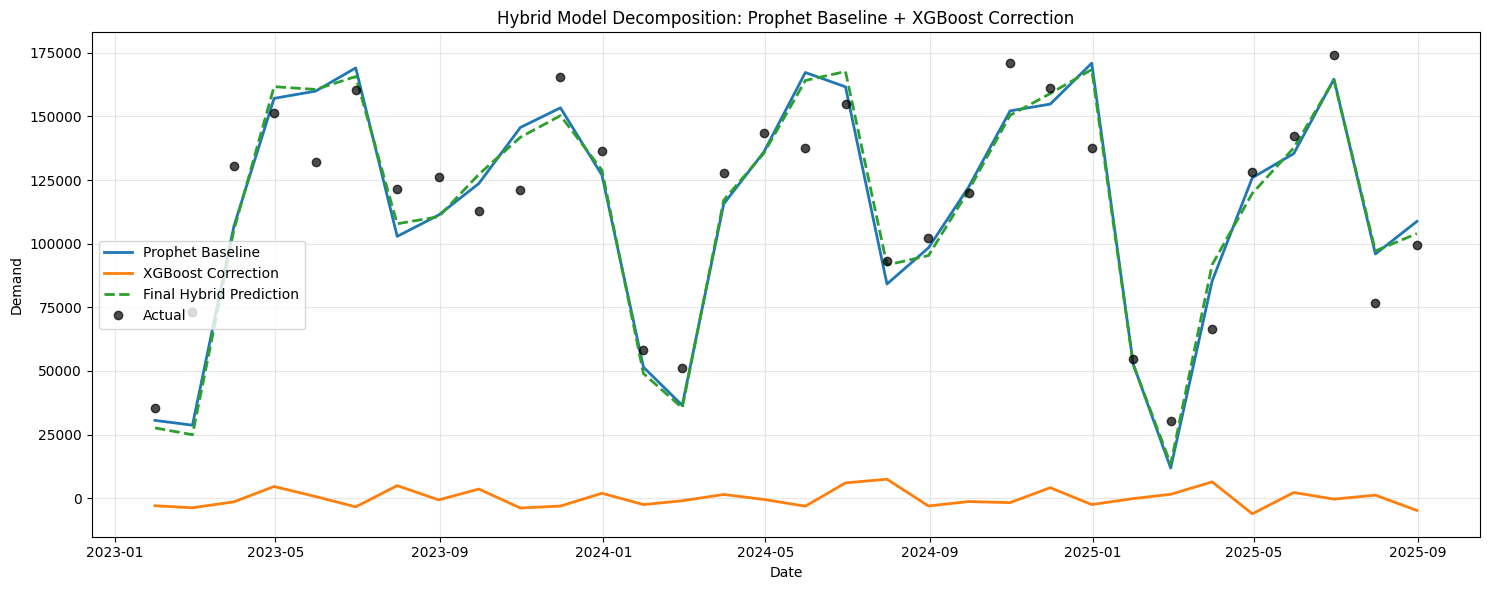


📊 Component Statistics (Validation):
Prophet baseline mean: 113987.4
XGBoost correction mean: 4.7
Final hybrid mean: 113992.1
Actual demand mean: 115486.2


In [7]:
# 8.3 Decomposition: How much does each component contribute?
# Validation set only
fig, ax = plt.subplots(figsize=(15, 6))

# Stack the contributions
ax.plot(df_valid['ds'], df_valid['prophet_hat'], label='Prophet Baseline', linewidth=2)
ax.plot(df_valid['ds'], valid_resid_pred, label='XGBoost Correction', linewidth=2)
ax.plot(df_valid['ds'], valid_hybrid, label='Final Hybrid Prediction', linewidth=2, linestyle='--')
ax.plot(df_valid['ds'], df_valid['y'], 'o', label='Actual', alpha=0.7, color='black')

ax.set_xlabel('Date')
ax.set_ylabel('Demand')
ax.set_title('Hybrid Model Decomposition: Prophet Baseline + XGBoost Correction')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Component Statistics (Validation):")
print(f"Prophet baseline mean: {df_valid['prophet_hat'].mean():.1f}")
print(f"XGBoost correction mean: {valid_resid_pred.mean():.1f}")
print(f"Final hybrid mean: {valid_hybrid.mean():.1f}")
print(f"Actual demand mean: {df_valid['y'].mean():.1f}")

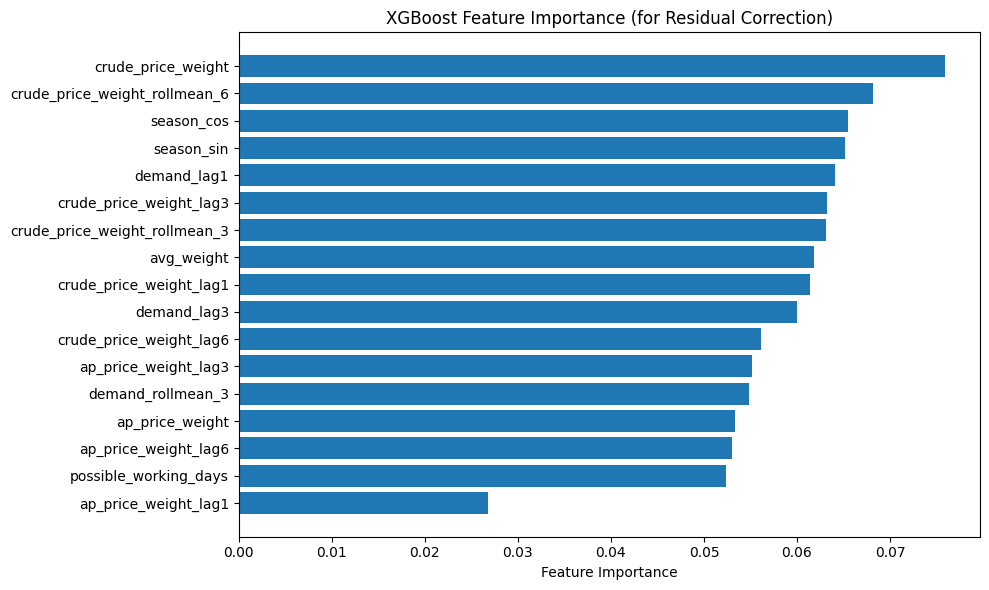


📊 XGBoost Feature Importance (for correcting Prophet errors):
  crude_price_weight: 0.0759
  crude_price_weight_rollmean_6: 0.0681
  season_cos: 0.0655
  season_sin: 0.0652
  demand_lag1: 0.0641
  crude_price_weight_lag3: 0.0632
  crude_price_weight_rollmean_3: 0.0631
  avg_weight: 0.0619
  crude_price_weight_lag1: 0.0614
  demand_lag3: 0.0600
  crude_price_weight_lag6: 0.0561
  ap_price_weight_lag3: 0.0552
  demand_rollmean_3: 0.0549
  ap_price_weight: 0.0533
  ap_price_weight_lag6: 0.0530
  possible_working_days: 0.0524
  ap_price_weight_lag1: 0.0268


In [8]:
# 8.2 XGBoost Feature Importance
importance_df = pd.DataFrame({
    'feature': reg_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(range(len(importance_df)), importance_df['importance'])
plt.yticks(range(len(importance_df)), importance_df['feature'])
plt.xlabel('Feature Importance')
plt.title('XGBoost Feature Importance (for Residual Correction)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📊 XGBoost Feature Importance (for correcting Prophet errors):")
for idx, row in importance_df.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

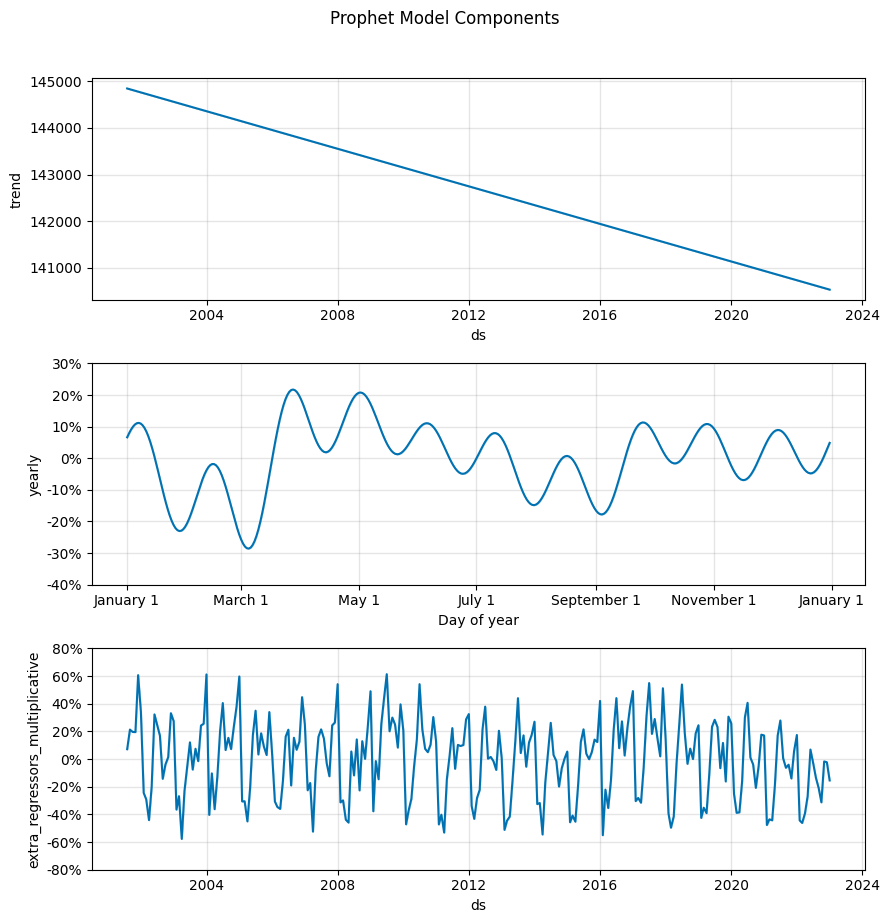

In [9]:
# 8.1 Prophet Components
fig = prophet_model.plot_components(p_train)
plt.suptitle('Prophet Model Components', y=1.02)
plt.tight_layout()
plt.show()

### 8. Component Analysis

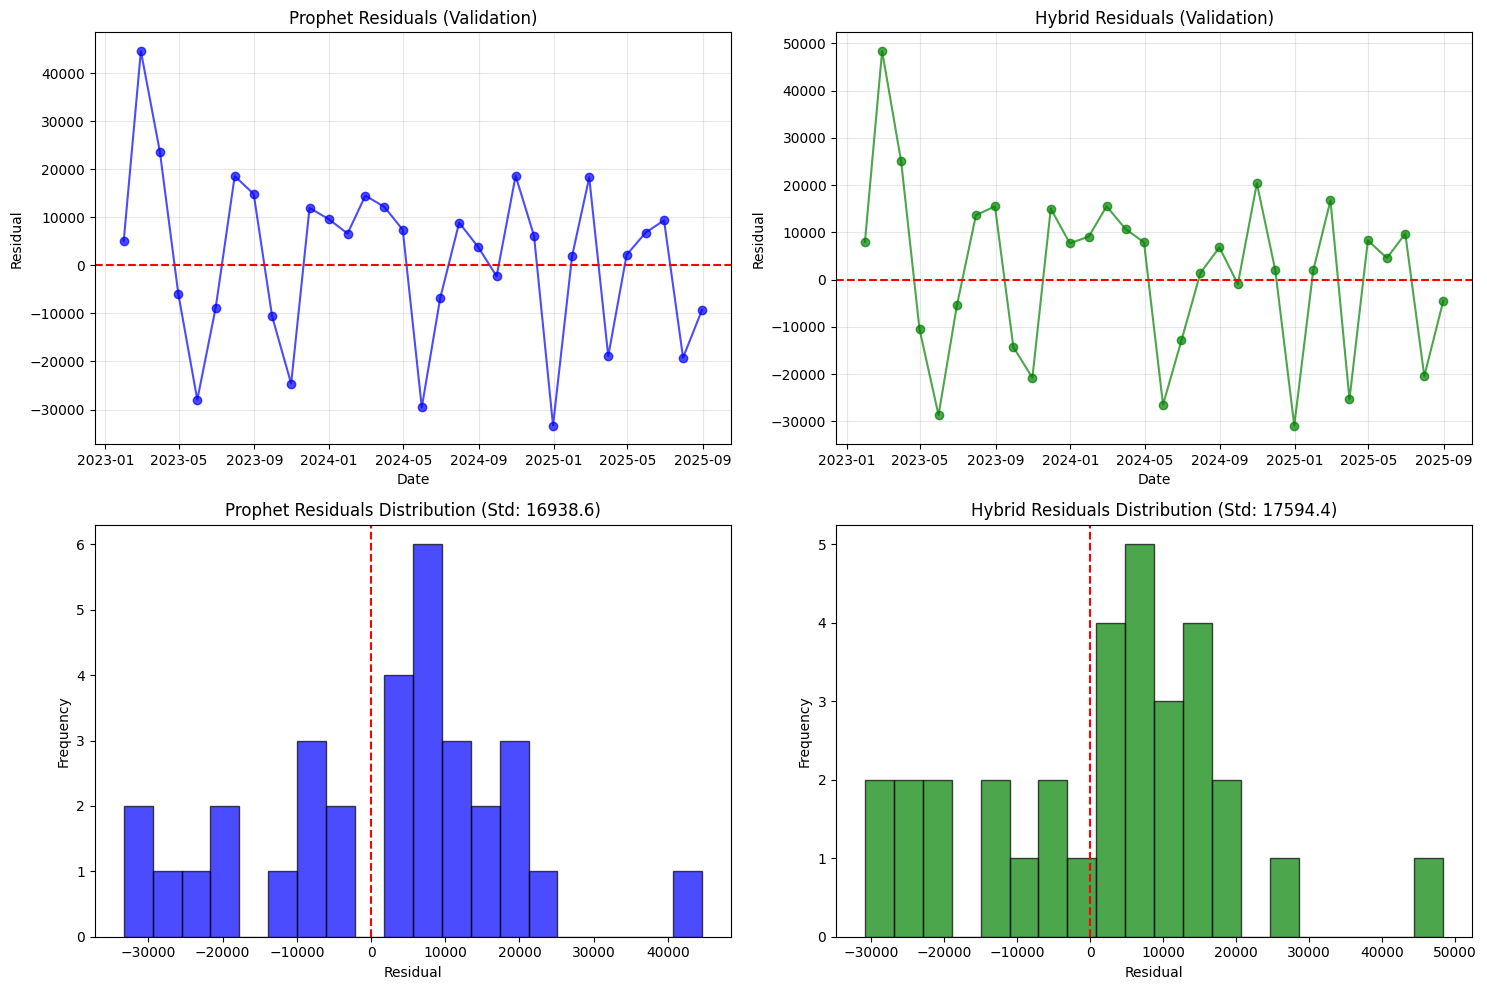

📊 Residual Analysis:
Prophet residuals std: 16938.6
Hybrid residuals std:  17594.4
Improvement: -3.9% reduction in residual variance


In [10]:
# 7.2 Residual Analysis
train_prophet_resid = df_train['y'].values - df_train['prophet_hat'].values
valid_prophet_resid = df_valid['y'].values - df_valid['prophet_hat'].values
train_hybrid_resid = df_train['y'].values - train_hybrid
valid_hybrid_resid = df_valid['y'].values - valid_hybrid

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Prophet residuals over time
axes[0, 0].plot(df_valid['ds'], valid_prophet_resid, 'o-', alpha=0.7, color='blue')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Prophet Residuals (Validation)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual')
axes[0, 0].grid(True, alpha=0.3)

# Hybrid residuals over time
axes[0, 1].plot(df_valid['ds'], valid_hybrid_resid, 'o-', alpha=0.7, color='green')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_title('Hybrid Residuals (Validation)')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Residual')
axes[0, 1].grid(True, alpha=0.3)

# Prophet residuals histogram
axes[1, 0].hist(valid_prophet_resid, bins=20, alpha=0.7, edgecolor='black', color='blue')
axes[1, 0].axvline(x=0, color='r', linestyle='--')
axes[1, 0].set_title(f'Prophet Residuals Distribution (Std: {valid_prophet_resid.std():.1f})')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')

# Hybrid residuals histogram
axes[1, 1].hist(valid_hybrid_resid, bins=20, alpha=0.7, edgecolor='black', color='green')
axes[1, 1].axvline(x=0, color='r', linestyle='--')
axes[1, 1].set_title(f'Hybrid Residuals Distribution (Std: {valid_hybrid_resid.std():.1f})')
axes[1, 1].set_xlabel('Residual')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("📊 Residual Analysis:")
print(f"Prophet residuals std: {valid_prophet_resid.std():.1f}")
print(f"Hybrid residuals std:  {valid_hybrid_resid.std():.1f}")
print(f"Improvement: {(1 - valid_hybrid_resid.std()/valid_prophet_resid.std())*100:.1f}% reduction in residual variance")

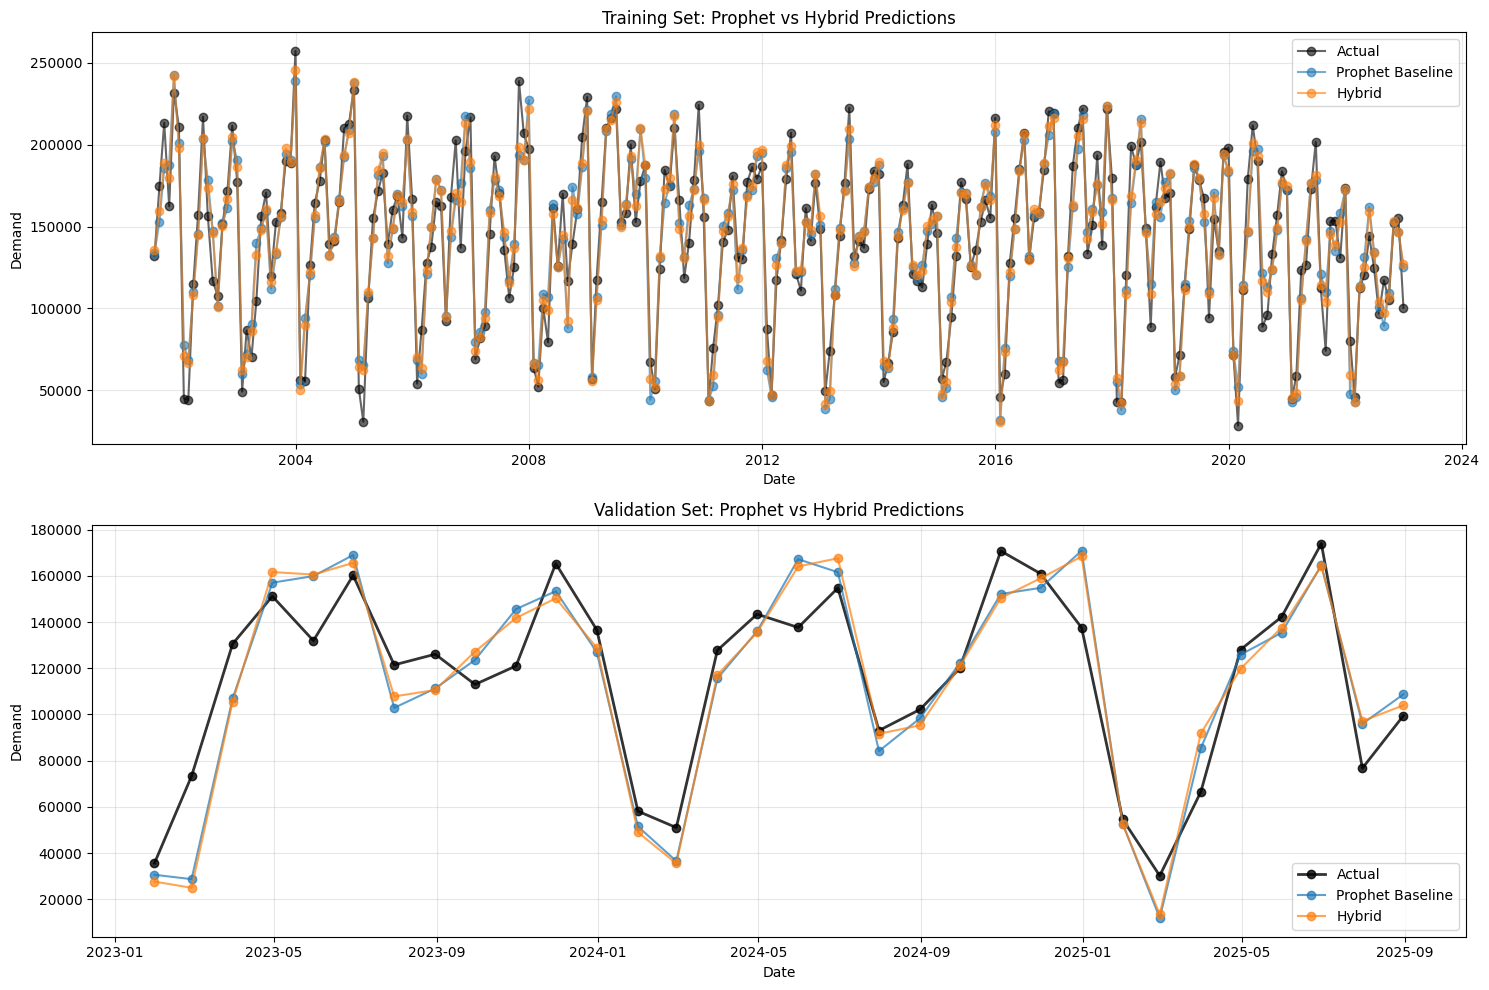

In [11]:
# 7.1 Predictions Comparison: Prophet vs Hybrid
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Training set
axes[0].plot(df_train['ds'], df_train['y'], 'o-', label='Actual', alpha=0.6, color='black')
axes[0].plot(df_train['ds'], df_train['prophet_hat'], 'o-', label='Prophet Baseline', alpha=0.6)
axes[0].plot(df_train['ds'], train_hybrid, 'o-', label='Hybrid', alpha=0.6)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Demand')
axes[0].set_title('Training Set: Prophet vs Hybrid Predictions')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].plot(df_valid['ds'], df_valid['y'], 'o-', label='Actual', alpha=0.8, color='black', linewidth=2)
axes[1].plot(df_valid['ds'], df_valid['prophet_hat'], 'o-', label='Prophet Baseline', alpha=0.7)
axes[1].plot(df_valid['ds'], valid_hybrid, 'o-', label='Hybrid', alpha=0.7)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Demand')
axes[1].set_title('Validation Set: Prophet vs Hybrid Predictions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7. Visualizations

### 6. Evaluate and Save Results